In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from joblib import load
from sklearn.model_selection import train_test_split

In [2]:
plt.rcParams["font.family"] = ["Microsoft JhengHei"]
plt.rcParams["axes.unicode_minus"] = False

## 錯誤分析

In [3]:
# 讀取原始資料
df = pd.read_csv(r'D:\Python\我的AI作品集\專案1_數學函數辨識\data\function_dataset.csv')

# 定義模型特徵
X = df.drop(columns=['sample_id', 'label', 'noise_sigma'])
y = df['label']
sample_id = df['sample_id']     # sample_id 不拿去訓練模型

In [4]:
# 分割測試資料
X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, y, sample_id, test_size=0.2, random_state=10, stratify=y)

In [5]:
# 載入最佳模型
best_model = load(r'D:\Python\我的AI作品集\專案1_數學函數辨識\models\best_model.joblib')

# 開始預測
y_pred = best_model.predict(X_test)

In [6]:
# 找出 Sine/Cosine 之間的錯誤點
cosine_to_sine = ((y_test == 'cosine') & (y_pred == 'sine'))
cosine_to_sine_index = X_test.index[cosine_to_sine]
sine_to_cosine = ((y_test == 'sine') & (y_pred == 'cosine'))
sine_to_cosine_index = X_test.index[sine_to_cosine]
print(f"Cosine 被預測成 Sine 的錯誤: 有 {cosine_to_sine.sum()} 個")
print(f"Sine 被預測成 Cosine 的錯誤: 有 {sine_to_cosine.sum()} 個\n")

Cosine 被預測成 Sine 的錯誤: 有 1 個
Sine 被預測成 Cosine 的錯誤: 有 4 個



In [7]:
# 建立錯誤樣本集
error_df = pd.DataFrame({'sample_id': id_test.values, 
                         'label': y_test.values, 
                         'predicted_label': y_pred})

In [8]:
error_df = error_df[((error_df['label']=='cosine') &
                     (error_df['predicted_label']=='sine')) | 
                    ((error_df['label']=='sine') & 
                     (error_df['predicted_label']=='cosine'))]

In [9]:
# 讀取metadata檔案
metadata = pd.read_csv(r'D:\Python\我的AI作品集\專案1_數學函數辨識\data\function_metadata.csv')
metadata = metadata[['sample_id', 'param_1', 'param_2', 'param_3', 'param_4', 'noise_sigma']]

In [10]:
# 透過樣本編號對應到 metadata
error_metadata = error_df.merge(metadata, on='sample_id', how='left', validate='one_to_one')
print("錯誤樣本:")
print(error_metadata[['sample_id', 'label', 'predicted_label', 'param_1', 
                      'param_2', 'param_3', 'param_4', 'noise_sigma']].to_string(index=False))

錯誤樣本:
 sample_id  label predicted_label  param_1  param_2   param_3   param_4  noise_sigma
      2727   sine          cosine 2.588530 2.392755  0.743937  0.883557     0.043728
      3150 cosine            sine 1.538318 1.275734 -0.756376 -0.093071     0.025731
      2719   sine          cosine 2.653467 3.370360  0.767241  0.713285     0.129856
      2866   sine          cosine 1.016743 2.730738  0.687624  0.052389     0.037746
      2531   sine          cosine 1.312797 3.375928  0.728364  0.895646     0.073758


In [11]:
# 分析兩種錯誤
cosine_sine_metadata = error_metadata[(error_metadata['label']=='cosine') & 
                                      (error_metadata['predicted_label']=='sine')]
sine_cosine_metadata = error_metadata[(error_metadata['label']=='sine') & 
                                      (error_metadata['predicted_label']=='cosine')]

In [12]:
print(f"Cosine → Sine 的 noise_sigma:\n{cosine_sine_metadata['noise_sigma'].describe()}\n")

Cosine → Sine 的 noise_sigma:
count    1.000000
mean     0.025731
std           NaN
min      0.025731
25%      0.025731
50%      0.025731
75%      0.025731
max      0.025731
Name: noise_sigma, dtype: float64



In [13]:
print(f"Sine → Cosine 的 noise_sigma:\n{sine_cosine_metadata['noise_sigma'].describe()}\n")

Sine → Cosine 的 noise_sigma:
count    4.000000
mean     0.071272
std      0.042115
min      0.037746
25%      0.042233
50%      0.058743
75%      0.087783
max      0.129856
Name: noise_sigma, dtype: float64



### 建立測試資料表

In [14]:
test_df = pd.DataFrame({'sample_id': id_test.values, 
                        'label': y_test.values, 
                        'predicted_label': y_pred})

In [15]:
test_df = test_df[test_df['label'].isin(['sine', 'cosine'])]
test_metadata = metadata.copy()     # 加入 metadata
test_df = test_df.merge(test_metadata, on='sample_id', how='left', validate='one_to_one')

### 將 noise_sigma 分成4個區間

In [16]:
bins = [0, 0.05, 0.10, 0.15, 0.20]        
labels = ['0.00 ~ 0.05', '0.05 ~ 0.10', '0.10 ~ 0.15', '0.15 ~ 0.20']
test_df['noise_range'] = pd.cut(test_df['noise_sigma'], bins=bins, labels=labels, include_lowest=True)

In [17]:
test_df['error'] = (test_df['label'] != test_df['predicted_label'])     # 判斷是否預測錯誤

In [18]:
# 計算每個 Noise 區間的錯誤率
noise_analysis = test_df.groupby('noise_range', observed=False).agg(total_samples=('error', 'count'),
                                                                    error_count=('error', 'sum'),
                                                                    error_rate=('error', 'mean'))
print(f"Noise Sigma 錯誤率分析:\n{noise_analysis.to_string(formatters={'error_rate': '{:.2%}'.format})}")

Noise Sigma 錯誤率分析:
             total_samples  error_count error_rate
noise_range                                       
0.00 ~ 0.05             99           11     11.11%
0.05 ~ 0.10             77            2      2.60%
0.10 ~ 0.15             22            1      4.55%
0.15 ~ 0.20              2            0      0.00%


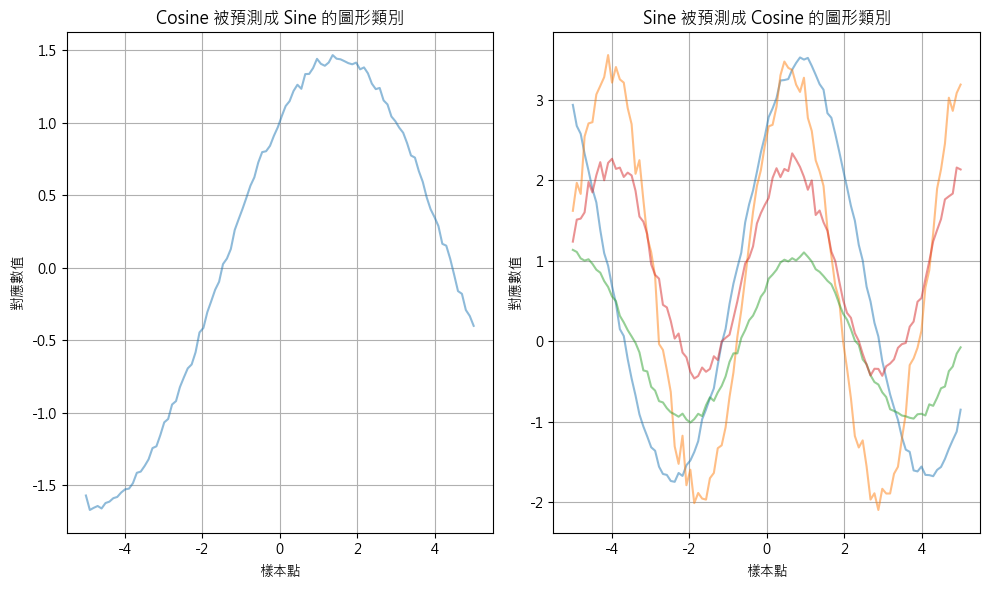

In [19]:
# 繪製圖表
xx = np.linspace(-5, 5, 100)            # Sample Points
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(1, 2, 1)
for index in cosine_to_sine_index:
    y_values = X_test.loc[index].values
    ax.plot(xx, y_values, alpha=0.5)
ax.set_xlabel("樣本點")
ax.set_ylabel("對應數值")
ax.set_title("Cosine 被預測成 Sine 的圖形類別")
ax.grid()

ax = fig.add_subplot(1, 2, 2)
for index in sine_to_cosine_index:
    y_values = X_test.loc[index].values
    ax.plot(xx, y_values, alpha=0.5)
ax.set_xlabel("樣本點")
ax.set_ylabel("對應數值")
ax.set_title("Sine 被預測成 Cosine 的圖形類別")
ax.grid()

plt.tight_layout()
plt.show()

## 參數分析

In [20]:
# Sine/Cosine 參數的錯誤分析
print(f"測試總樣本數: {len(test_df)}")
print(f"預測錯誤數量: {test_df['error'].sum()}")
print(f"Sine被誤判成Cosine: {((test_df['label']=='sine') & (test_df['predicted_label']=='cosine')).sum()}")
print(f"Cosine被誤判成Sine: {((test_df['label']=='cosine') & (test_df['predicted_label']=='sine')).sum()}")

others = test_df['error'].sum() - \
    ((test_df['label']=='sine') & (test_df['predicted_label']=='cosine')).sum() - \
    ((test_df['label']=='cosine') & (test_df['predicted_label']=='sine')).sum()
print(f"其他錯誤: {others}")

測試總樣本數: 200
預測錯誤數量: 14
Sine被誤判成Cosine: 4
Cosine被誤判成Sine: 1
其他錯誤: 9


In [21]:
# 處理其他錯誤的部分
other_errors = test_df[(test_df['error']) &
    ~(((test_df['label'] == 'sine') & (test_df['predicted_label'] == 'cosine')) |
      ((test_df['label'] == 'cosine') & (test_df['predicted_label'] == 'sine')))]
print(other_errors[['sample_id', 'label', 'predicted_label', 
                    'param_1', 'param_2', 'param_3', 'param_4', 'noise_sigma']].to_string(index=False))

 sample_id  label predicted_label  param_1  param_2   param_3   param_4  noise_sigma
      2972   sine      reciprocal 0.586733 1.433519  0.584998  0.968800     0.017313
      2624   sine     exponential 0.512333 1.457153 -0.577926  0.451366     0.008916
      2963   sine       quadratic 2.788041 1.435764 -0.743275  0.854322     0.078646
      2604   sine      reciprocal 0.630057 1.043649  0.637004 -0.884349     0.015350
      3440 cosine       quadratic 0.700641 1.253436 -0.153228 -0.429745     0.010696
      3360 cosine     logarithmic 0.531047 1.715815  0.609564 -0.571901     0.015850
      3200 cosine       quadratic 0.682252 1.094040  0.058031 -0.477254     0.026332
      3123 cosine     logarithmic 1.257471 1.002833  0.691868 -0.867172     0.046208
      2561   sine     logarithmic 1.399558 1.080525 -0.585143 -0.179498     0.029459


In [22]:
print(f"整體錯誤率: {test_df['error'].mean():.2%}")

整體錯誤率: 7.00%


In [23]:
# 正確 vs 錯誤的參數統計
parameters = ['param_1', 'param_2', 'param_3', 'param_4']
parameter_summary = []
for parameter in parameters:
    correct_data = test_df[test_df['error'] == False][parameter]
    error_data = test_df[test_df['error'] == True][parameter]
    parameter_summary.append({'Parameter': parameter,
                              'Correct Mean': correct_data.mean(),
                              'Correct Median': correct_data.median(),
                              'Error Mean': error_data.mean(),
                              'Error Median': error_data.median(),
                              'Mean Difference': (error_data.mean() - correct_data.mean())})
para_sum_df = pd.DataFrame(parameter_summary)

In [24]:
# 正確樣本 vs 錯誤樣本參數比較
print(para_sum_df.to_string(index=False, formatters={'Correct Mean': '{:.4f}'.format,
                                                     'Correct Median': '{:.4f}'.format,
                                                     'Error Mean': '{:.4f}'.format,
                                                     'Error Median': '{:.4f}'.format,
                                                     'Mean Difference': '{:.4f}'.format}))

Parameter Correct Mean Correct Median Error Mean Error Median Mean Difference
  param_1       1.7613         1.7911     1.2999       1.1371         -0.4614
  param_2       2.4802         2.5592     1.7616       1.4346         -0.7186
  param_3      -0.0003        -0.0713     0.1923       0.5973          0.1926
  param_4       0.0153         0.0483     0.0940      -0.0203          0.0787


### 分析每個參數的數值區間

In [25]:
# --各參數區間的錯誤率--
for parameter in parameters:
    # 使用四分位數分組, 每個區間大約包含相同數量的資料
    test_df[f'{parameter}_range'] = pd.qcut(test_df[parameter], q=4, duplicates='drop')
    analysis = test_df.groupby(f'{parameter}_range', observed=False).agg(
        total_samples=('error', 'count'),
        error_count=('error', 'sum'),
        error_rate=('error', 'mean')
    )
    print(analysis.to_string(formatters={'error_rate': '{:.2%}'.format}))
    print("-"*100)

                total_samples  error_count error_rate
param_1_range                                        
(0.511, 1.208]             50            7     14.00%
(1.208, 1.756]             50            4      8.00%
(1.756, 2.27]              50            0      0.00%
(2.27, 3.0]                50            3      6.00%
----------------------------------------------------------------------------------------------------
                             total_samples  error_count error_rate
param_2_range                                                     
(0.9999999999999999, 1.685]             50            9     18.00%
(1.685, 2.454]                          50            2      4.00%
(2.454, 3.139]                          50            1      2.00%
(3.139, 3.986]                          50            2      4.00%
----------------------------------------------------------------------------------------------------
                   total_samples  error_count error_rate
param_3_range  

In [26]:
para_sum_df.to_csv(r'D:\Python\我的AI作品集\專案1_數學函數辨識\data\parameter_analysis.csv', index=False)

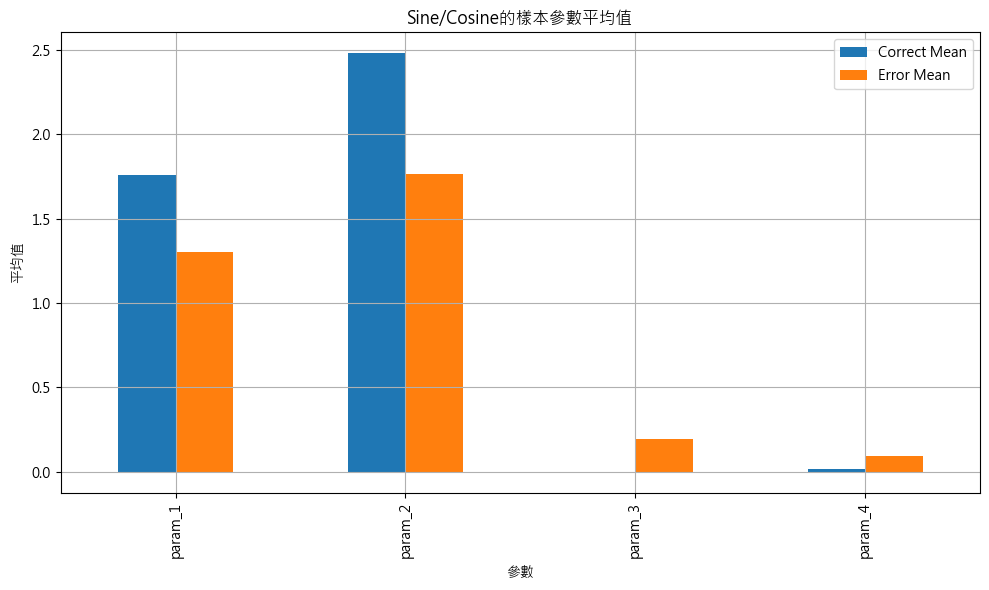

In [27]:
# 繪製圖表(正確/錯誤樣本的參數平均值)
plot_data = para_sum_df[['Parameter', 'Correct Mean', 'Error Mean']]
plot_data = plot_data.set_index('Parameter')
plot_data.plot(kind='bar', figsize=(10, 6))
plt.xlabel('參數')
plt.ylabel('平均值')
plt.title('Sine/Cosine的樣本參數平均值')
plt.xticks()
plt.grid()
plt.tight_layout()
plt.show()